##### My naive implementation of gradient descent with randomly drawn initial guesses.

This notebook is to display and visualize my implementations, but they will be referenced from a regular notebook of the type .py

In [66]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
def gradient(f,x,epsilon = 0.001):
    """
    Calculates gradient of f at x
    ------------------------

    f : function of choice
    x : where the computation takes place
    epsilon : small difference
    -------------------------

    Uses the two point method
    """

    try:
        dim = len(x)

        Gradient = np.zeros(dim)

        for i in range(dim):
            y = x.copy()
            z = x.copy()
            y[i]+=epsilon
            z[i]-=epsilon
            partial = (f(z)-f(y))/(2*epsilon)

            Gradient[i] = partial

        return Gradient

    except: 

        print("Something went terribly wrong in the gradient calculation")
    

In [68]:
def gradient_descent_random(f,ite,zeta,dr = 0.99,stopping = 0.01, low =-1, high = 1,epsilon_gradient = 0.001,max =5, decay = True):
    """"
    gradient descent with random starting points and a decay rate decay rate
    ------------------------
    f : function of choice (does not have to be vectorized)
    ite : iterations
    zeta: scale
    dr : decay rate
    low & high : the max and min which upon the guesses are drawn upon for every param.
    epsilon_gradient : small difference passed to the gradient
    decay : off / on
    -----------------------
    """""
    import inspect
    sig = inspect.signature(f)
    params = sig.parameters
    dim = len(params)


    from functools import wraps

    def vectorize_args(func): # For vectorizing f_vec
        """Wrap func(x1, x2, ..., xn) -> f([x1, ..., xn])."""
        @wraps(func)
        def wrapper(vec):
            return func(*vec)
        return wrapper
    
    f_vec = vectorize_args(f)
    runs = []
    starts = np.random.uniform(low, high,size=(ite,dim))

    steps =[]
    
    for x in starts:
        t =zeta
        v = x.copy()
        step =[]
        for i in range(max):
            
            q=v + t*gradient(f_vec,v)
            if np.linalg.norm(q-v)**(1/2)< stopping:
                break
            else:
                v = q 
            
            t = t*dr 
            step.append(v)
        steps.append(step)
        runs.append(v)

    runs = np.array(runs)
    outcomes = [f_vec(i) for i in runs]

    ind =np.argsort(outcomes)

    return min(outcomes),runs[ind], outcomes,steps
    
        

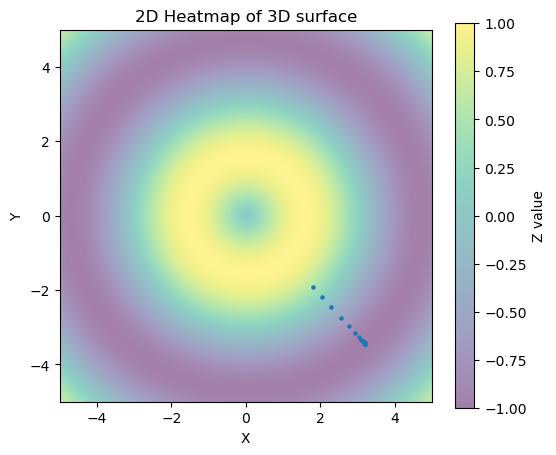

In [69]:
def func(x,y):
    return np.sin(np.sqrt(x**2+y**2))




x = np.arange(-5, 5, 0.01)
y = np.arange(-5, 5, 0.01)
X, Y = np.meshgrid(x, y)
Z = func(X,Y)





plt.figure(figsize=(6,5))
plt.imshow(Z,               # 2D array of values
           extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower',  # so (0,0) is bottom-left
           cmap='viridis',  # choose a colormap
           alpha=0.5)
plt.colorbar(label='Z value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Heatmap of 3D surface')




o,o,o,steps= gradient_descent_random(func, ite=5,low=-4,high=4, zeta =0.4,stopping=0.01,max =100)


x_coords = [v[0] for v in steps[1]] 
y_coords = [v[1] for v in steps[1]] 

plt.scatter(x_coords,y_coords,s=5)
plt.show()

# To Be Continued...